Célula 1: Configuração, Importações e Limpeza dos Dados (Data Cleaning)
Esta célula prepara o ambiente, carrega o seu arquivo local e garante que as colunas e corrompidos sejam corrigidos antes de qualquer análise.

In [14]:
# =====================================================================
# CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS E HIGIENIZAÇÃO DA BASE
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados especificando o ponto e vírgula (sep=';') e encoding ocidental comum
caminho_arquivo = r"C:\Users\kelvi\Downloads\servidorPorOrgao.csv"

try:
    # Tentativa 1: Ponto e vírgula com encoding utf-8
    df = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8')
except (UnicodeDecodeError, ParserError):
    # Tentativa 2: Caso o arquivo use a codificação padrão do Excel no Brasil (latin1)
    df = pd.read_csv(caminho_arquivo, sep=';', encoding='latin1')

# 2. Limpar caracteres invisíveis nos nomes das colunas e aspas extras
df.columns = df.columns.str.replace('"', '').str.strip()

# 3. Remover a coluna vazia "Unnamed: 5" se ela existir
if 'Unnamed: 5' in df.columns:
    df = df.drop(columns=['Unnamed: 5'])

# Exibir as primeiras 5 linhas para confirmar o sucesso
print("--- Amostra dos Dados Carregados com Sucesso! ---")
print(df.head())

--- Amostra dos Dados Carregados com Sucesso! ---
         Órgão Superior Lotação                           Órgão Lotação  \
0                Sem informação                    Ministério da Defesa   
1                Sem informação        Tribunal Regional Eleitoral - PI   
2                Sem informação    Prefeitura Municipal de Vitória - ES   
3  Ministério da Infraestrutura  Companhia das Docas do Estado da Bahia   
4                Sem informação            Ministério da Infraestrutura   

   Servidores  Inativos  Pensionistas  
0           1         0             0  
1           1         0             0  
2           1         0             0  
3           3         0             0  
4           3         0             0  


Célula 2: Análise Estatística, Agrupamento e Correlação (AED)
Esta célula calcula os totais do país, agrupa os dados por ministério e roda o teste de correlação de Pearson para quantificar a relação entre ativos e inativos.

In [15]:
# =====================================================================
# CÉLULA 2: ANÁLISE EXPLORATÓRIA E CORRELAÇÃO NATIVA DO PANDAS
# =====================================================================
print("--- Resumo Estatístico Geral ---")
print(df.describe())

# 1. Somar o total absoluto de pessoas em cada categoria no país
total_ativos = df['Servidores'].sum()
total_inativos = df['Inativos'].sum()
total_pensionistas = df['Pensionistas'].sum()

print("\n--- Totais Acumulados no Executivo Federal ---")
print(f"Total de Servidores Ativos: {total_ativos:,}".replace(",", "."))
print(f"Total de Inativos (Aposentados): {total_inativos:,}".replace(",", "."))
print(f"Total de Pensionistas: {total_pensionistas:,}".replace(",", "."))

# 2. Agrupar por Órgão Superior para consolidar os ministérios
df_grouped = df.groupby("Órgão Superior Lotação")[["Servidores", "Inativos", "Pensionistas"]].sum().reset_index()
df_grouped["Total_Vinculos"] = df_grouped["Servidores"] + df_grouped["Inativos"] + df_grouped["Pensionistas"]

# Ordenar e exibir os 10 maiores
df_grouped = df_grouped.sort_values(by="Total_Vinculos", ascending=False)
print("\n--- Top 10 Órgãos Superiores por Total de Vínculos ---")
print(df_grouped.head(10).to_string(index=False))

# 3. Cálculo de Correlação de Pearson Nativa (Rápido e 100% Seguro)
# Usamos a função .corr() do Pandas, que não depende do pacote SciPy
corr_ativos_inativos = df['Servidores'].corr(df['Inativos'])

print("\n--- Validação Estatística ---")
print(f"Correlação de Pearson entre Ativos e Inativos: {corr_ativos_inativos:.4f}")

if corr_ativos_inativos > 0.9:
    print("Resultado Técnico: Força de correlação estatística classificada como 'Muito Forte (Quase Perfeita)'.")

--- Resumo Estatístico Geral ---
          Servidores      Inativos   Pensionistas
count     325.000000    325.000000     325.000000
mean     3104.726154   1794.009231    1571.356923
std     14034.303634   8751.377271   10204.002056
min         0.000000      0.000000       0.000000
25%        15.000000      0.000000       0.000000
50%       674.000000     24.000000       9.000000
75%      2148.000000    555.000000     215.000000
max    214868.000000  88151.000000  137255.000000

--- Totais Acumulados no Executivo Federal ---
Total de Servidores Ativos: 1.009.036
Total de Inativos (Aposentados): 583.053
Total de Pensionistas: 510.691

--- Top 10 Órgãos Superiores por Total de Vínculos ---
                   Órgão Superior Lotação  Servidores  Inativos  Pensionistas  Total_Vinculos
                     MINISTERIO DA DEFESA      363011    195414        265759          824184
                   Ministério da Educação      345614    116106         41091          502811
                     

Célula 3: Visualização Gráfica (Data Visualization)
Esta célula gera o gráfico de barras comparativo do Top 10 órgãos. Como está isolada, você pode rodar apenas ela se quiser ajustar cores, tamanhos ou exportar a imagem.

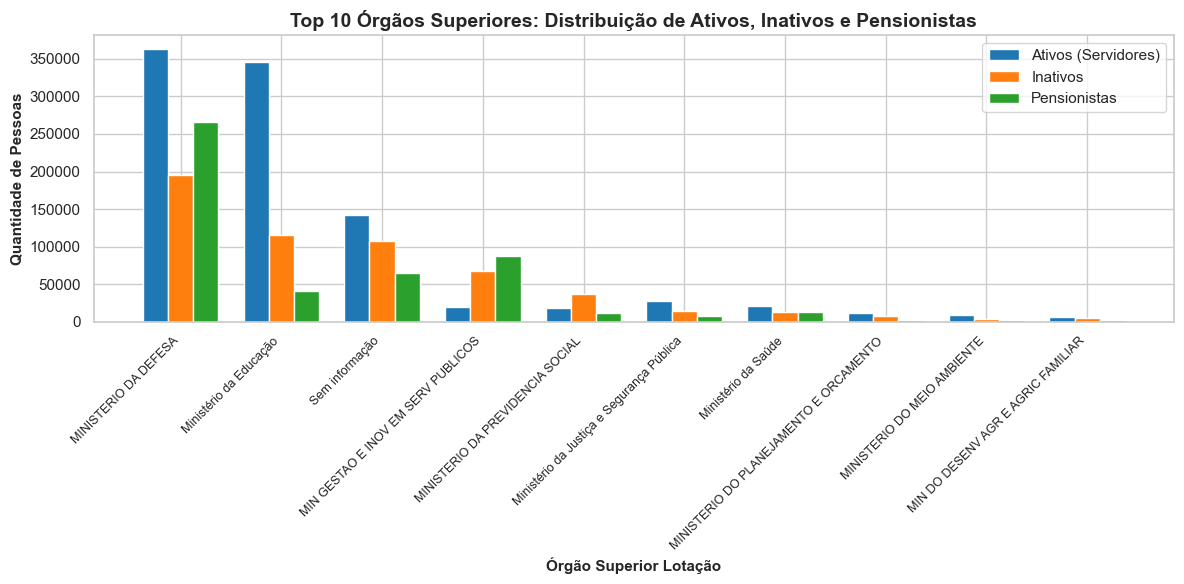

In [16]:
# =====================================================================
# CÉLULA 3: GERAÇÃO DA VISUALIZAÇÃO GRÁFICA
# =====================================================================
# Configurar o estilo visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Selecionar os 10 maiores para plotagem
top_10 = df_grouped.head(10)
x = np.arange(len(top_10))
width = 0.25

# Plotar as barras de Ativos, Inativos e Pensionistas lado a lado
plt.bar(x - width, top_10['Servidores'], width, label='Ativos (Servidores)', color='#1f77b4')
plt.bar(x, top_10['Inativos'], width, label='Inativos', color='#ff7f0e')
plt.bar(x + width, top_10['Pensionistas'], width, label='Pensionistas', color='#2ca02c')

# Customizar eixos, títulos e legendas
plt.xlabel('Órgão Superior Lotação', fontsize=11, fontweight='bold')
plt.ylabel('Quantidade de Pessoas', fontsize=11, fontweight='bold')
plt.title('Top 10 Órgãos Superiores: Distribuição de Ativos, Inativos e Pensionistas', fontsize=14, fontweight='bold')
plt.xticks(x, top_10['Órgão Superior Lotação'], rotation=45, ha='right', fontsize=9)
plt.legend()
plt.tight_layout()

# Exibir o gráfico diretamente no Notebook
plt.show()